In [46]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [3]:
df = pd.read_csv("data/telematics_syn-032021.csv")

In [8]:
df.describe()

,Duration,Insured.age,Car.age,Credit.score,Annual.miles.drive,Years.noclaims,Territory,Annual.pct.driven,Total.miles.driven,Pct.drive.mon,...,Left.turn.intensity10,Left.turn.intensity11,Left.turn.intensity12,Right.turn.intensity08,Right.turn.intensity09,Right.turn.intensity10,Right.turn.intensity11,Right.turn.intensity12,NB_Claim,AMT_Claim
count,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,...,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.00000,100000.000000
mean,314.204060,51.378950,5.639720,800.888870,9124.122908,28.839960,56.531390,0.502294,4833.575303,0.139365,...,551.574010,487.340690,447.758420,843.461830,565.056100,326.654840,246.713120,198.753690,0.04494,137.602253
std,79.746222,15.467075,4.062135,83.382316,3826.144730,16.123717,24.036518,0.299189,4545.943016,0.042807,...,14687.929802,14198.331308,13719.790281,11630.185503,10657.402935,9460.244357,8977.569994,8585.177049,0.21813,1264.320056
min,27.000000,16.000000,-2.000000,422.000000,0.000000,0.000000,11.000000,0.002740,0.095298,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000
25%,200.000000,39.000000,2.000000,766.000000,6213.710000,15.000000,35.000000,0.249315,1529.897500,0.120894,...,0.000000,0.000000,0.000000,11.000000,3.000000,0.000000,0.000000,0.000000,0.00000,0.000000
50%,365.000000,51.000000,5.000000,825.000000,7456.452000,29.000000,62.000000,0.490411,3468.287765,0.137909,...,3.000000,1.000000,0.000000,122.000000,43.000000,7.000000,2.000000,0.000000,0.00000,0.000000
75%,366.000000,63.000000,8.000000,856.000000,12427.420000,41.000000,78.000000,0.753425,6779.876842,0.155203,...,30.000000,9.000000,2.000000,680.000000,321.000000,81.000000,27.000000,9.000000,0.00000,0.000000
max,366.000000,103.000000,20.000000,900.000000,56731.172300,79.000000,91.000000,1.000000,47282.603936,0.998172,...,794380.000000,793926.000000,793170.000000,841210.000000,841207.000000,841200.000000,841176.000000,841144.000000,3.00000,104074.886700


In [51]:
len(df.columns)

52

In [60]:
telematics_cols = ["Accel","Brake","Left","Right","Pct","Avgdays","Total","Annual.pct"]
telematics_metrics = []

for x in df.columns:
    for y in telematics_cols:
        if y in x:
            telematics_metrics.append(x)
tradiational_metrics = [x for x in df.columns if x not in telematics_metrics]

In [61]:
print(len(tradiational_metrics),len(telematics_metrics))

13 39


In [62]:
traditional_df = df[tradiational_metrics]
telematics_df = df[telematics_metrics]

In [78]:
traditional_df["pred"] = 365*traditional_df["NB_Claim"]/traditional_df["Duration"]

/var/folders/qj/3zmdfhnn4bxgc68lbfycnlt40000gn/T/ipykernel_12283/3230328046.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  traditional_df["pred"] = 365*traditional_df["NB_Claim"]/traditional_df["Duration"]


In [79]:
traditional_df

,Duration,Insured.age,Insured.sex,Car.age,Marital,Car.use,Credit.score,Region,Annual.miles.drive,Years.noclaims,Territory,NB_Claim,AMT_Claim,pred
0,366,45,Male,-1,Married,Commute,609.0,Urban,6213.71,25,70,1,5100.171753,0.997268
1,182,44,Female,3,Married,Commute,575.0,Urban,12427.42,20,26,1,883.554840,2.005495
2,184,48,Female,6,Married,Commute,847.0,Urban,12427.42,14,84,0,0.000000,0.000000
3,183,71,Male,6,Married,Private,842.0,Urban,6213.71,43,30,0,0.000000,0.000000
4,183,84,Male,10,Married,Private,856.0,Urban,6213.71,65,70,0,0.000000,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99995,182,61,Male,10,Single,Private,824.0,Urban,6213.71,42,32,0,0.000000,0.000000
99996,192,48,Male,3,Married,Commute,850.0,Urban,12427.42,32,84,0,0.000000,0.000000
99997,184,50,Male,2,Single,Commute,650.0,Rural,6213.71,31,71,0,0.000000,0.000000
99998,184,76,Male,2,Married,Private,811.0,Rural,6213.71,58,87,0,0.000000,0.000000


<Axes: ylabel='Frequency'>

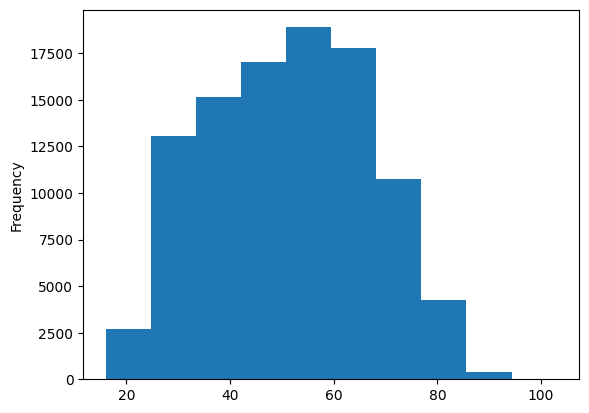

In [81]:
traditional_df["Insured.age"].plot(kind='hist')

In [72]:
telematics_df

,Annual.pct.driven,Total.miles.driven,Pct.drive.mon,Pct.drive.tue,Pct.drive.wed,Pct.drive.thr,Pct.drive.fri,Pct.drive.sat,Pct.drive.sun,Pct.drive.2hrs,...,Left.turn.intensity08,Left.turn.intensity09,Left.turn.intensity10,Left.turn.intensity11,Left.turn.intensity12,Right.turn.intensity08,Right.turn.intensity09,Right.turn.intensity10,Right.turn.intensity11,Right.turn.intensity12
0,0.849315,8864.376247,0.148070,0.152466,0.143494,0.132412,0.169418,0.131632,0.122508,0.002607,...,7.0,3.0,1.0,0.0,0.0,3.0,1.0,0.0,0.0,0.0
1,0.465753,8092.308208,0.147686,0.136917,0.135046,0.188125,0.159724,0.148017,0.084485,0.000377,...,469.0,225.0,58.0,24.0,11.0,1099.0,615.0,219.0,101.0,40.0
2,0.520548,3225.832512,0.153735,0.097124,0.129706,0.182424,0.168658,0.157462,0.110891,0.013296,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.065753,253.024528,0.106702,0.056437,0.134039,0.185479,0.253381,0.235744,0.028218,0.000000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.441096,4374.379634,0.123807,0.169661,0.157235,0.165071,0.182776,0.105034,0.096416,0.002335,...,80.0,22.0,2.0,0.0,0.0,325.0,111.0,18.0,4.0,2.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99995,0.161644,903.231641,0.068358,0.110253,0.124156,0.141347,0.089213,0.216832,0.249842,0.000000,...,20.0,8.0,0.0,0.0,0.0,4.0,4.0,0.0,0.0,0.0
99996,0.167123,2870.045192,0.160821,0.124073,0.144771,0.088325,0.155679,0.201336,0.124996,0.009000,...,442.0,184.0,50.0,17.0,10.0,357.0,175.0,48.0,22.0,11.0
99997,0.117808,935.538222,0.095132,0.076684,0.132180,0.124667,0.167627,0.255885,0.147825,0.002352,...,0.0,0.0,0.0,0.0,0.0,3.0,0.0,0.0,0.0,0.0
99998,0.473973,4287.600459,0.106783,0.151199,0.165762,0.159595,0.166981,0.162158,0.087521,0.004425,...,1.0,0.0,0.0,0.0,0.0,6.0,1.0,0.0,0.0,0.0


In [67]:
df_encoded = pd.get_dummies(traditional_df, columns=['Insured.sex',"Marital", "Car.use","Region"])

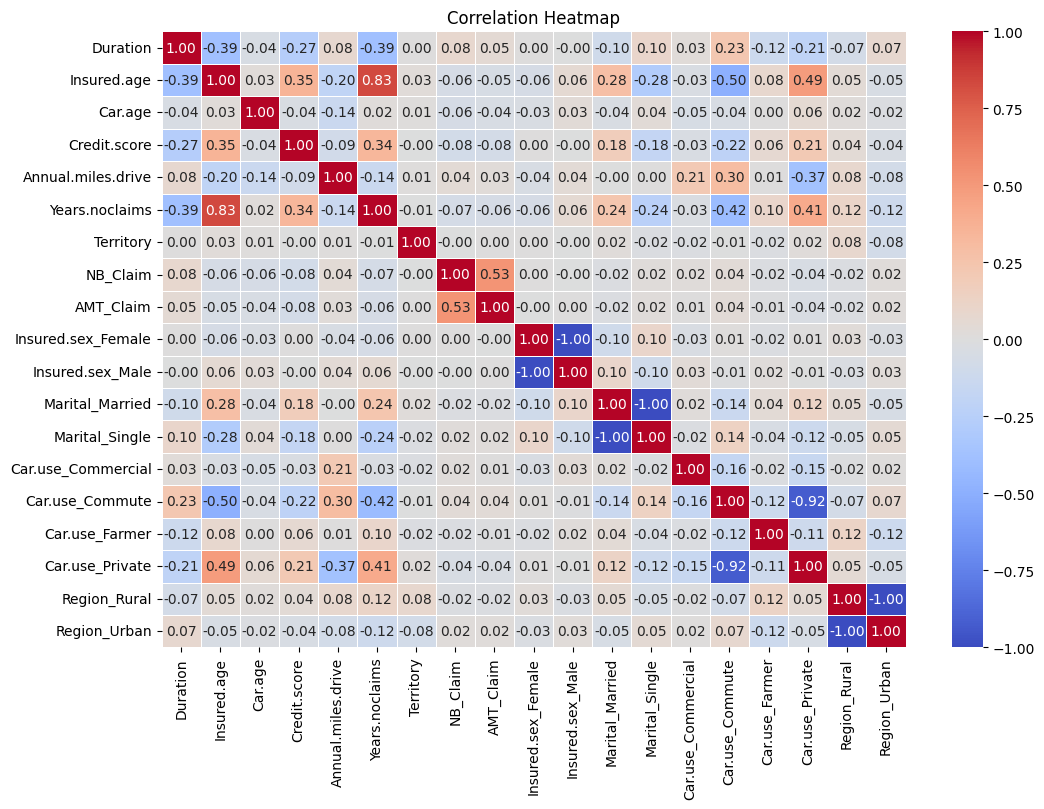

In [71]:
plt.figure(figsize=(12, 8)) # Optional: Adjust figure size for better readability
sns.heatmap(df_encoded.corr(), annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Correlation Heatmap')
plt.show()

AttributeError: module 'matplotlib.pyplot' has no attribute 'heatmap'

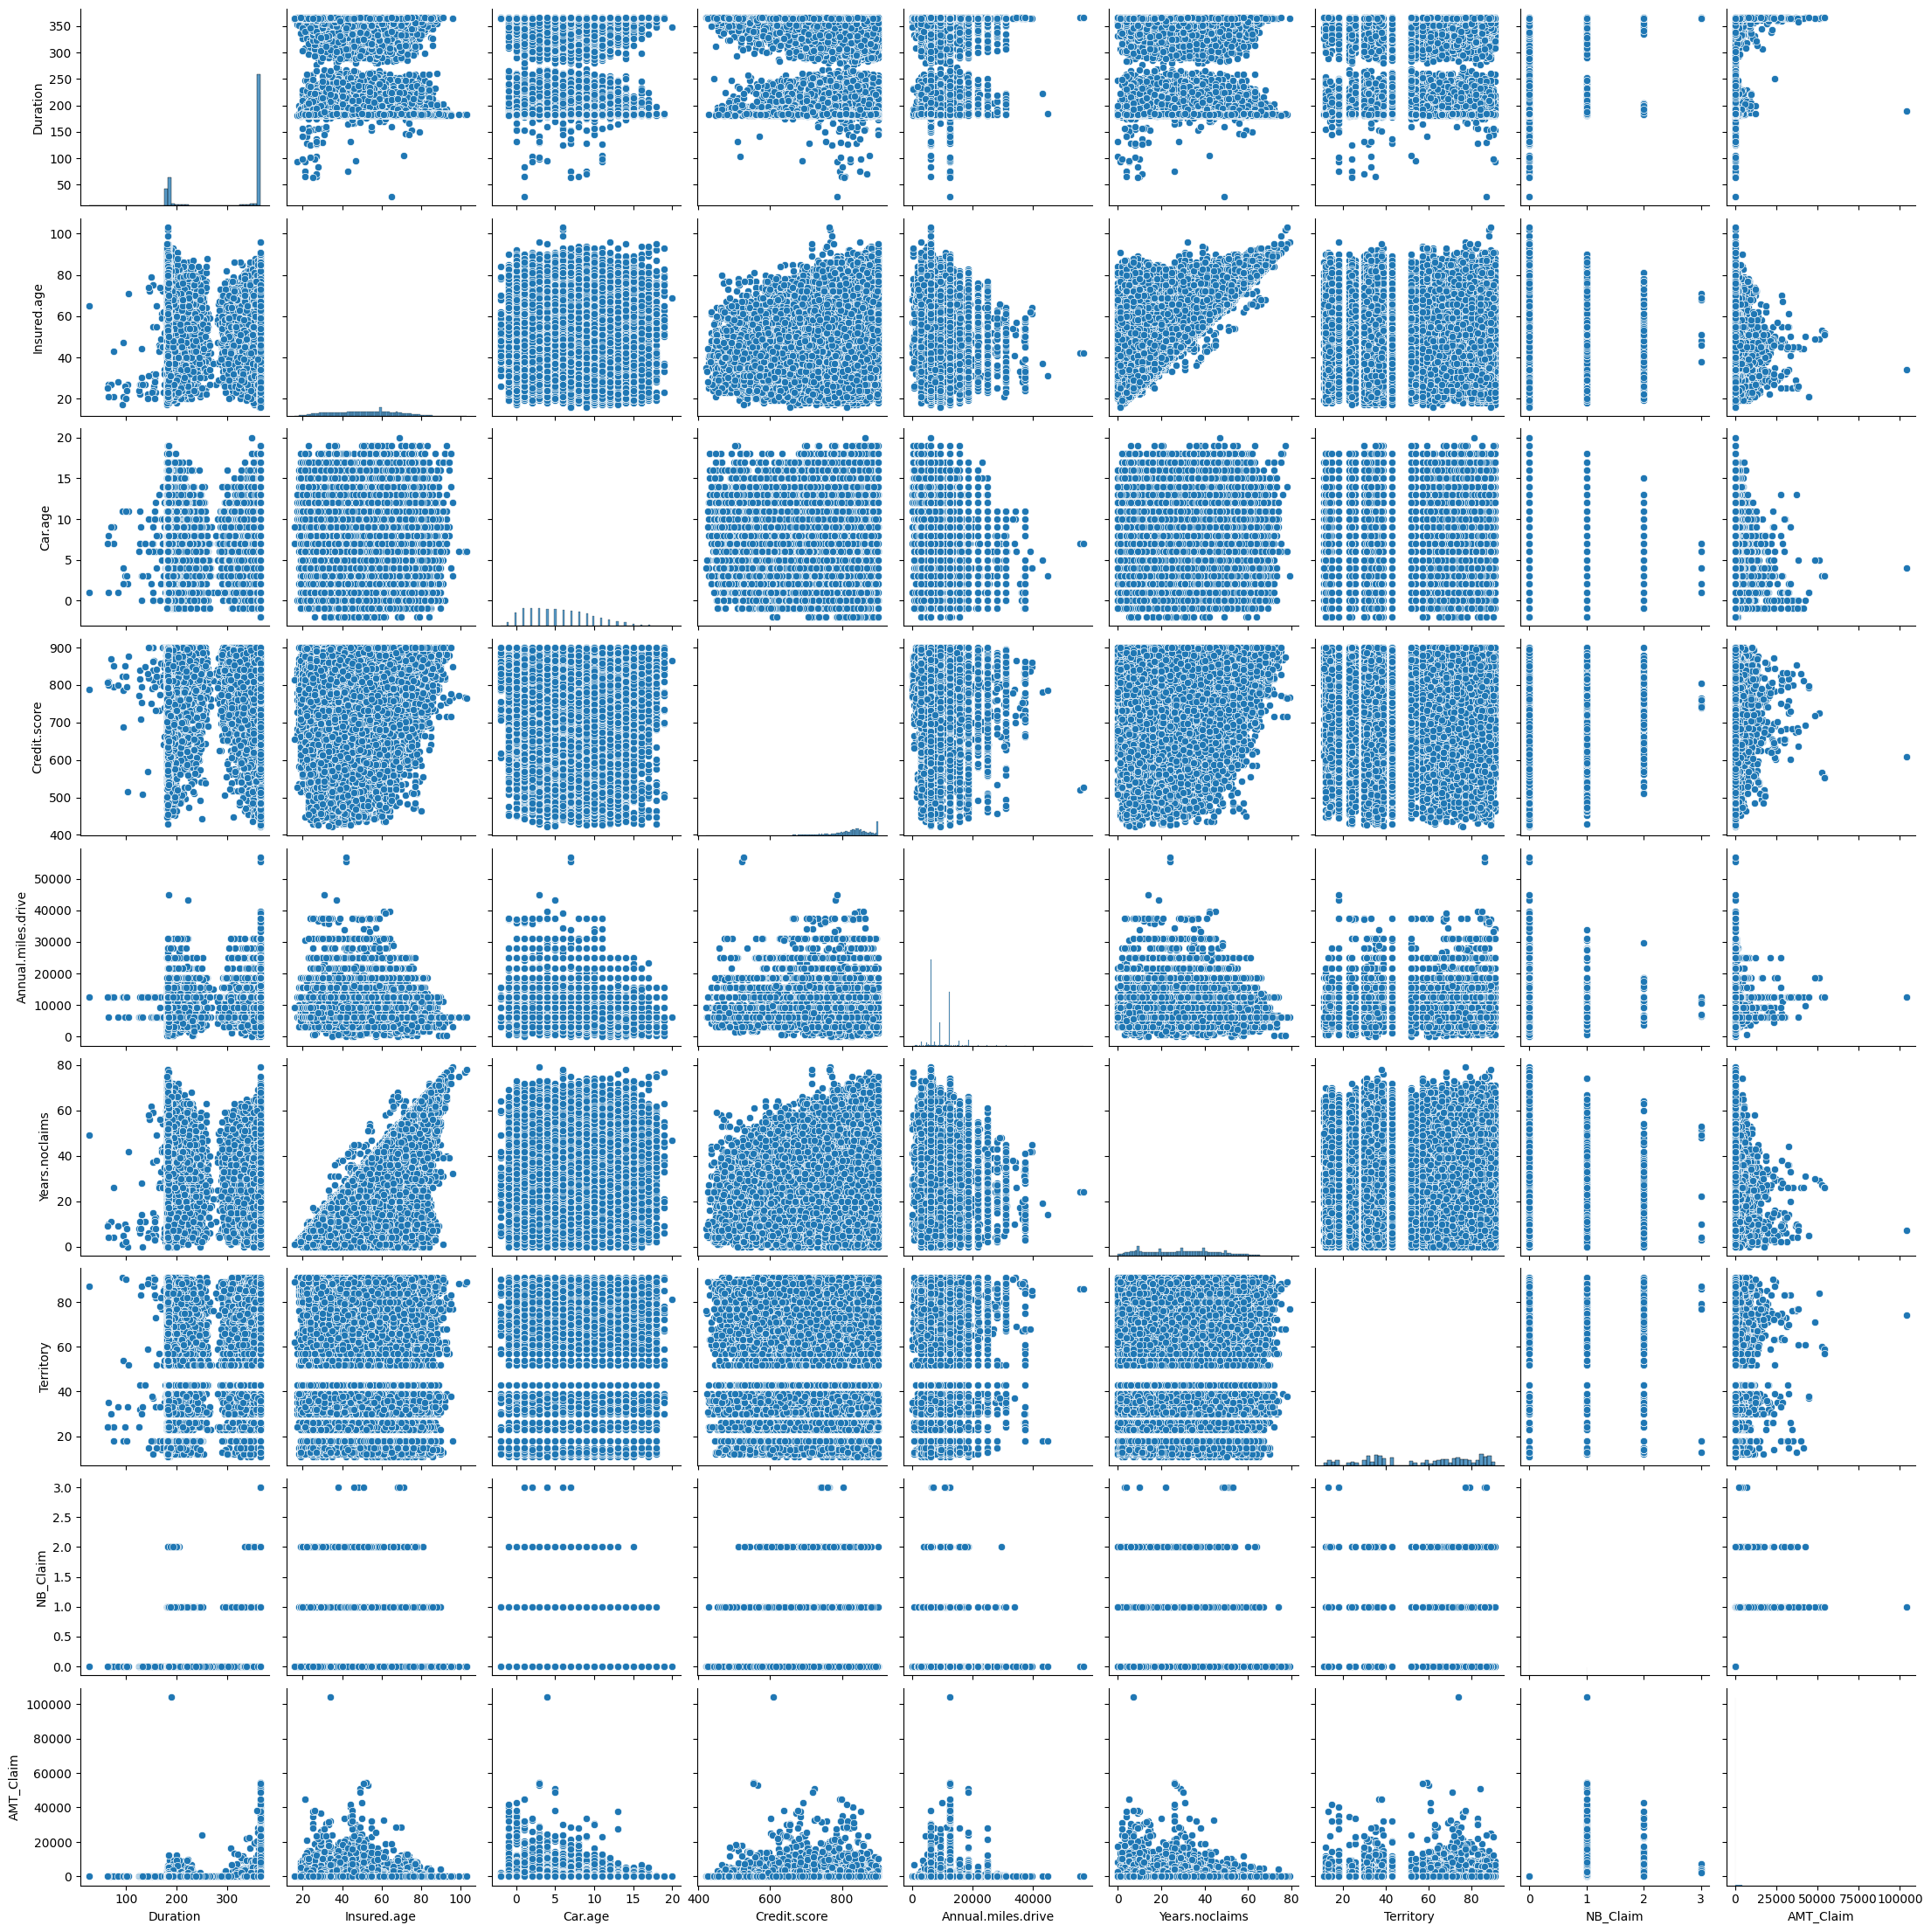

In [65]:
# sns.pairplot(traditional_df)

In [10]:
print(df.columns

Index(['Duration', 'Insured.age', 'Insured.sex', 'Car.age', 'Marital',
       'Car.use', 'Credit.score', 'Region', 'Annual.miles.drive',
       'Years.noclaims', 'Territory', 'Annual.pct.driven',
       'Total.miles.driven', 'Pct.drive.mon', 'Pct.drive.tue', 'Pct.drive.wed',
       'Pct.drive.thr', 'Pct.drive.fri', 'Pct.drive.sat', 'Pct.drive.sun',
       'Pct.drive.2hrs', 'Pct.drive.3hrs', 'Pct.drive.4hrs', 'Pct.drive.wkday',
       'Pct.drive.wkend', 'Pct.drive.rush am', 'Pct.drive.rush pm',
       'Avgdays.week', 'Accel.06miles', 'Accel.08miles', 'Accel.09miles',
       'Accel.11miles', 'Accel.12miles', 'Accel.14miles', 'Brake.06miles',
       'Brake.08miles', 'Brake.09miles', 'Brake.11miles', 'Brake.12miles',
       'Brake.14miles', 'Left.turn.intensity08', 'Left.turn.intensity09',
       'Left.turn.intensity10', 'Left.turn.intensity11',
       'Left.turn.intensity12', 'Right.turn.intensity08',
       'Right.turn.intensity09', 'Right.turn.intensity10',
       'Right.turn.intensity1

In [11]:
df.head()

,Duration,Insured.age,Insured.sex,Car.age,Marital,Car.use,Credit.score,Region,Annual.miles.drive,Years.noclaims,...,Left.turn.intensity10,Left.turn.intensity11,Left.turn.intensity12,Right.turn.intensity08,Right.turn.intensity09,Right.turn.intensity10,Right.turn.intensity11,Right.turn.intensity12,NB_Claim,AMT_Claim
0,366,45,Male,-1,Married,Commute,609.0,Urban,6213.71,25,...,1.0,0.0,0.0,3.0,1.0,0.0,0.0,0.0,1,5100.171753
1,182,44,Female,3,Married,Commute,575.0,Urban,12427.42,20,...,58.0,24.0,11.0,1099.0,615.0,219.0,101.0,40.0,1,883.554840
2,184,48,Female,6,Married,Commute,847.0,Urban,12427.42,14,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,0.000000
3,183,71,Male,6,Married,Private,842.0,Urban,6213.71,43,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,0.000000
4,183,84,Male,10,Married,Private,856.0,Urban,6213.71,65,...,2.0,0.0,0.0,325.0,111.0,18.0,4.0,2.0,0,0.000000


<Axes: xlabel='NB_Claim'>

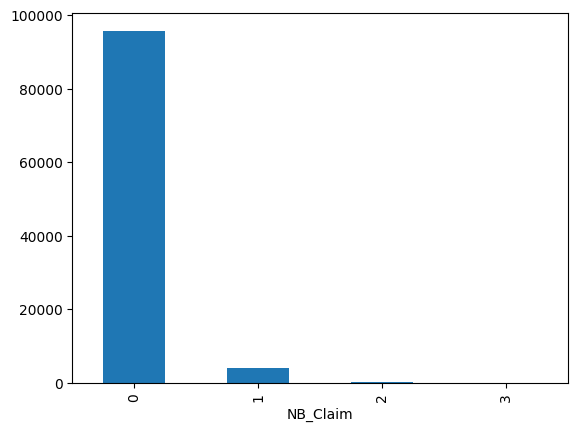

In [22]:
df["NB_Claim"].value_counts().plot(kind = 'bar')

In [75]:
df["Duration"].mean()

np.float64(314.20406)